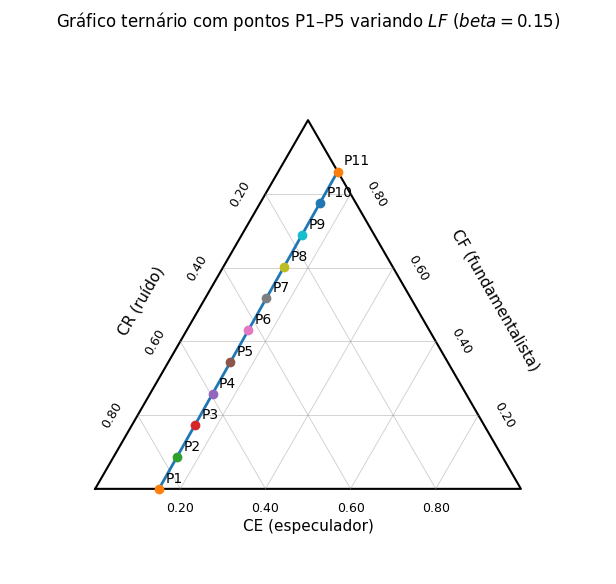

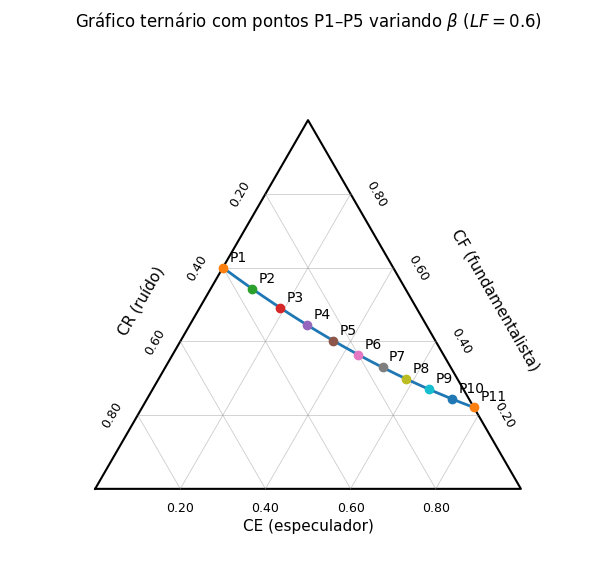

Tabela de pontos ternários - variação de LF


,Ponto,Cenário,LF,beta,CF,CE,CR,x,y
0,P1,Variação de LF,0.0,0.15,0.000000,0.150000,0.850,0.150000,0.000000
1,P2,Variação de LF,0.1,0.15,0.086071,0.148929,0.765,0.191965,0.074539
2,P3,Variação de LF,0.2,0.15,0.172142,0.147858,0.680,0.233929,0.149079
3,P4,Variação de LF,0.3,0.15,0.258212,0.146788,0.595,0.275894,0.223618
4,P5,Variação de LF,0.4,0.15,0.344283,0.145717,0.510,0.317858,0.298158
5,P6,Variação de LF,0.5,0.15,0.430354,0.144646,0.425,0.359823,0.372697
6,P7,Variação de LF,0.6,0.15,0.516425,0.143575,0.340,0.401788,0.447237
7,P8,Variação de LF,0.7,0.15,0.602496,0.142504,0.255,0.443752,0.521776
8,P9,Variação de LF,0.8,0.15,0.688566,0.141434,0.170,0.485717,0.596316
9,P10,Variação de LF,0.9,0.15,0.774637,0.140363,0.085,0.527681,0.670855


Tabela de pontos ternários - variação de beta


,Ponto,Cenário,LF,beta,CF,CE,CR,x,y
0,P1,Variação de beta,0.6,0.0,0.600000,0.000000,0.40,0.300000,0.519615
1,P2,Variação de beta,0.6,0.1,0.542902,0.097098,0.36,0.368549,0.470167
2,P3,Variação de beta,0.6,0.2,0.491238,0.188762,0.32,0.434381,0.425425
3,P4,Variação de beta,0.6,0.3,0.444491,0.275509,0.28,0.497755,0.384940
4,P5,Variação de beta,0.6,0.4,0.402192,0.357808,0.24,0.558904,0.348309
5,P6,Variação de beta,0.6,0.5,0.363918,0.436082,0.20,0.618041,0.315163
6,P7,Variação de beta,0.6,0.6,0.329287,0.510713,0.16,0.675357,0.285171
7,P8,Variação de beta,0.6,0.7,0.297951,0.582049,0.12,0.731024,0.258033
8,P9,Variação de beta,0.6,0.8,0.269597,0.650403,0.08,0.785201,0.233478
9,P10,Variação de beta,0.6,0.9,0.243942,0.716058,0.04,0.838029,0.211260


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from IPython.display import display

# -----------------------------
# Modelo dos coeficientes
# -----------------------------
def coefficients(LF, beta):
    CF = LF * np.exp(-beta)
    CR = (1 - beta) * (1 - LF)
    CE = 1 - CF - CR
    return CF, CE, CR

# -----------------------------
# Conversão ternária -> cartesiana
# topo = CF, esquerda = CR, direita = CE
# -----------------------------
V_CR = np.array([0.0, 0.0])
V_CE = np.array([1.0, 0.0])
V_CF = np.array([0.5, sqrt(3) / 2.0])

def ternary_to_cartesian(CF, CE, CR):
    total = CF + CE + CR
    CF, CE, CR = CF / total, CE / total, CR / total
    p = CF * V_CF + CE * V_CE + CR * V_CR
    return p[0], p[1]

# -----------------------------
# Desenho da malha ternária
# -----------------------------
def draw_ternary_axes(ax):
    triangle = np.array([V_CR, V_CE, V_CF, V_CR])
    ax.plot(triangle[:, 0], triangle[:, 1], linewidth=1.5, color='black')

    # Major ticks for grid lines and labels
    ticks_major = np.array([0.2, 0.4, 0.6, 0.8])

    # Draw grid lines
    for t in ticks_major:
        # Lines of constant CF
        p1_cf_grid = ternary_to_cartesian(t, 0, 1 - t)
        p2_cf_grid = ternary_to_cartesian(t, 1 - t, 0)
        ax.plot([p1_cf_grid[0], p2_cf_grid[0]], [p1_cf_grid[1], p2_cf_grid[1]], linewidth=0.6, alpha=0.4, color='gray')

        # Lines of constant CE
        p1_ce_grid = ternary_to_cartesian(0, t, 1 - t)
        p2_ce_grid = ternary_to_cartesian(1 - t, t, 0)
        ax.plot([p1_ce_grid[0], p2_ce_grid[0]], [p1_ce_grid[1], p2_ce_grid[1]], linewidth=0.6, alpha=0.4, color='gray')

        # Lines of constant CR
        p1_cr_grid = ternary_to_cartesian(0, 1 - t, t)
        p2_cr_grid = ternary_to_cartesian(1 - t, 0, t)
        ax.plot([p1_cr_grid[0], p2_cr_grid[0]], [p1_cr_grid[1], p2_cr_grid[1]], linewidth=0.6, alpha=0.4, color='gray')

    # Add numerical labels along each edge
    label_offset = 0.03 # Distance from the edge for labels

    for t in ticks_major:
        # CR axis (left side, CE=0)
        # Point on the left edge for a given CR value (t)
        x_cr, y_cr = ternary_to_cartesian(1 - t, 0, t) # (CF, CE, CR) = (1-t, 0, t)
        ax.text(x_cr - label_offset, y_cr, f'{t:.2f}', ha='right', va='center', fontsize=9, rotation=60)

        # CE axis (bottom side, CF=0)
        # Point on the bottom edge for a given CE value (t)
        x_ce, y_ce = ternary_to_cartesian(0, t, 1 - t) # (CF, CE, CR) = (0, t, 1-t)
        ax.text(x_ce, y_ce - label_offset, f'{t:.2f}', ha='center', va='top', fontsize=9, rotation=0)

        # CF axis (right side, CR=0)
        # Point on the right edge for a given CF value (t)
        x_cf, y_cf = ternary_to_cartesian(t, 1 - t, 0) # (CF, CE, CR) = (t, 1-t, 0)
        ax.text(x_cf + label_offset, y_cf, f'{t:.2f}', ha='left', va='center', fontsize=9, rotation=-60)


    # Labels for the components, placed at the middle of each side
    # Midpoint of CR-CE side (bottom edge, CF=0)
    mid_CR_CE_x, mid_CR_CE_y = (V_CR[0] + V_CE[0]) / 2, (V_CR[1] + V_CE[1]) / 2
    ax.text(mid_CR_CE_x, mid_CR_CE_y - 0.07, "CE (especulador)", ha="center", va="top", fontsize=11)

    # Midpoint of CF-CR side (left edge, CE=0)
    mid_CF_CR_x, mid_CF_CR_y = (V_CF[0] + V_CR[0]) / 2, (V_CF[1] + V_CR[1]) / 2
    ax.text(mid_CF_CR_x - 0.08, mid_CF_CR_y + 0.01, "CR (ruído)", ha="right", va="center", fontsize=11, rotation=60)

    # Midpoint of CF-CE side (right edge, CR=0)
    mid_CF_CE_x, mid_CF_CE_y = (V_CF[0] + V_CE[0]) / 2, (V_CF[1] + V_CE[1]) / 2
    ax.text(mid_CF_CE_x + 0.08, mid_CF_CE_y + 0.01, "CF (fundamentalista)", ha="left", va="center", fontsize=11, rotation=-60)

    ax.set_aspect("equal")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, sqrt(3) / 2 + 0.2)
    ax.axis("off")

# -----------------------------
# Pontos de referência
# -----------------------------
beta_fixed = 0.15
LF_marks = [0.00, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.00]

LF_rows = []
for idx, LF in enumerate(LF_marks, start=1):
    CF, CE, CR = coefficients(LF, beta_fixed)
    x, y = ternary_to_cartesian(CF, CE, CR)
    LF_rows.append({
        "Ponto": f"P{idx}",
        "Cenário": "Variação de LF",
        "LF": round(LF, 4),
        "beta": round(beta_fixed, 4),
        "CF": CF,
        "CE": CE,
        "CR": CR,
        "x": x,
        "y": y
    })

LF_df = pd.DataFrame(LF_rows)

LF_values = np.linspace(0, 1, 200)
curve_lf = []
for LF in LF_values:
    CF, CE, CR = coefficients(LF, beta_fixed)
    if (CF >= 0) and (CE >= 0) and (CR >= 0):
        curve_lf.append(ternary_to_cartesian(CF, CE, CR))
curve_lf = np.array(curve_lf)

fig, ax = plt.subplots(figsize=(8, 7))
draw_ternary_axes(ax)
ax.plot(curve_lf[:, 0], curve_lf[:, 1], linewidth=2)
for _, row in LF_df.iterrows():
    ax.plot(row["x"], row["y"], marker="o")
    ax.text(row["x"] + 0.015, row["y"] + 0.015, row["Ponto"], fontsize=10)
ax.set_title(rf"Gráfico ternário com pontos P1–P5 variando $LF$ ($beta={beta_fixed}$)")
plt.show()

# -----------------------------
# Pontos de referência para beta
# -----------------------------
LF_fixed = 0.60
beta_marks = [0.00,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.00]

beta_rows = []
for idx, beta in enumerate(beta_marks, start=1):
    CF, CE, CR = coefficients(LF_fixed, beta)
    x, y = ternary_to_cartesian(CF, CE, CR)
    beta_rows.append({
        "Ponto": f"P{idx}",
        "Cenário": "Variação de beta",
        "LF": round(LF_fixed, 4),
        "beta": round(beta, 4),
        "CF": CF,
        "CE": CE,
        "CR": CR,
        "x": x,
        "y": y
    })

beta_df = pd.DataFrame(beta_rows)

beta_values = np.linspace(0, 1, 200)
curve_beta = []
for beta in beta_values:
    CF, CE, CR = coefficients(LF_fixed, beta)
    if (CF >= 0) and (CE >= 0) and (CR >= 0):
        curve_beta.append(ternary_to_cartesian(CF, CE, CR))
curve_beta = np.array(curve_beta)

fig, ax = plt.subplots(figsize=(8, 7))
draw_ternary_axes(ax)
ax.plot(curve_beta[:, 0], curve_beta[:, 1], linewidth=2)
for _, row in beta_df.iterrows():
    ax.plot(row["x"], row["y"], marker="o")
    ax.text(row["x"] + 0.015, row["y"] + 0.015, row["Ponto"], fontsize=10)
ax.set_title(rf"Gráfico ternário com pontos P1–P5 variando $\beta$ ($LF={LF_fixed}$)")
plt.show()

# -----------------------------
# Tabelas formatadas
# -----------------------------
for df in [LF_df, beta_df]:
    for col in ["CF", "CE", "CR", "x", "y"]:
        df[col] = df[col].round(6)

print("Tabela de pontos ternários - variação de LF")
display(LF_df)
print("Tabela de pontos ternários - variação de beta")
display(beta_df)